In [104]:
import numpy as np
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [105]:
df=pd.read_csv('/content/Airline_Delay_Cause.csv')
df.sample(5)

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
151720,2017,2,F9,Frontier Airlines Inc.,FLL,"Fort Lauderdale, FL: Fort Lauderdale-Hollywood...",28.0,4.0,0.11,0.19,...,0.00,2.99,1.0,0.0,182.0,4.0,5.0,27.0,0.0,146.0
89277,2020,1,NK,Spirit Airlines,CAK,"Akron, OH: Akron-Canton Regional",46.0,9.0,2.36,0.00,...,0.00,4.52,0.0,0.0,395.0,94.0,0.0,108.0,0.0,193.0
33077,2022,7,MQ,Envoy Air,SRQ,"Sarasota/Bradenton, FL: Sarasota/Bradenton Int...",5.0,2.0,1.00,0.00,...,0.00,0.88,1.0,0.0,41.0,17.0,0.0,3.0,0.0,21.0
152466,2017,2,DL,Delta Air Lines Inc.,SJC,"San Jose, CA: Norman Y. Mineta San Jose Intern...",278.0,37.0,14.66,1.85,...,0.00,11.32,0.0,0.0,1880.0,707.0,129.0,251.0,0.0,793.0
152197,2017,2,AA,American Airlines Inc.,SJU,"San Juan, PR: Luis Munoz Marin International",490.0,53.0,25.92,1.23,...,0.34,7.84,1.0,0.0,3319.0,1910.0,60.0,561.0,10.0,778.0


In [118]:
df.describe()

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,179338.000000,179338.000000,178997.000000,178747.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000
mean,2019.480082,6.485725,327.816969,58.709086,18.572643,2.035742,17.094929,0.145307,20.778477,6.830103,0.779572,3863.310676,1325.546199,209.113426,819.949284,6.839941,1501.854875
std,2.410204,3.463516,931.001446,164.378035,47.389651,6.894812,56.279604,0.702149,64.912766,41.446756,3.490499,11902.153241,4067.786987,791.817638,3178.603458,40.440497,4878.178427
min,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2018.000000,3.000000,41.000000,6.000000,1.960000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,288.000000,91.000000,0.000000,28.000000,0.000000,54.000000
50%,2020.000000,6.000000,89.000000,15.000000,5.400000,0.220000,3.300000,0.000000,4.290000,1.000000,0.000000,900.000000,321.000000,12.000000,124.000000,0.000000,286.000000
75%,2022.000000,9.000000,218.000000,40.000000,14.700000,1.620000,9.860000,0.000000,13.010000,3.000000,1.000000,2547.000000,986.000000,131.000000,401.000000,0.000000,964.000000
max,2023.000000,12.000000,21977.000000,4176.000000,1293.910000,266.420000,1884.420000,58.690000,2069.070000,4951.000000,160.000000,438783.000000,196944.000000,31960.000000,112018.000000,3760.000000,227959.000000


In [107]:
df.isnull().sum()

,0
year,0
month,0
carrier,0
carrier_name,0
airport,0
airport_name,0
arr_flights,341
arr_del15,591
carrier_ct,341
weather_ct,341


In [108]:
df['airport_name'].nunique()

420

<ipython-input-109-3590978555>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['arr_delay'])


<Axes: xlabel='arr_delay', ylabel='Density'>

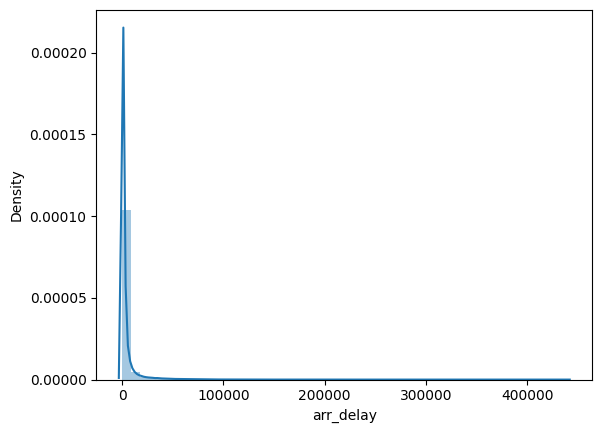

In [109]:
sns.distplot(df['arr_delay'])

<ipython-input-110-3633615808>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delay_causes.index, y=delay_causes.values, palette='Set2')


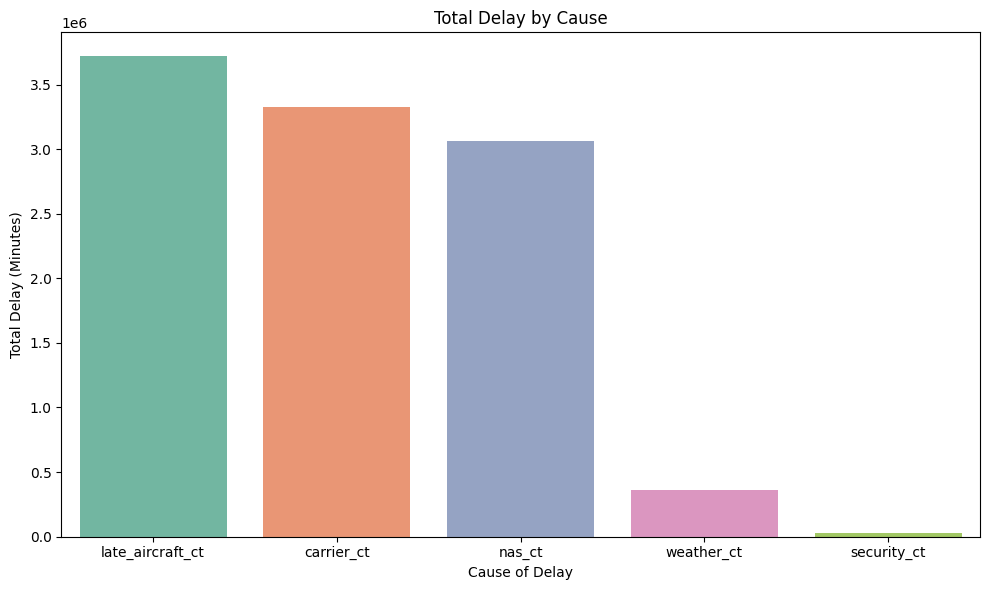

In [110]:
delay_causes = df[['carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct']].sum().sort_values(ascending=False)

# Bar plot of delay causes
plt.figure(figsize=(10, 6))
sns.barplot(x=delay_causes.index, y=delay_causes.values, palette='Set2')
plt.title('Total Delay by Cause')
plt.ylabel('Total Delay (Minutes)')
plt.xlabel('Cause of Delay')
plt.tight_layout()
plt.show()

<ipython-input-111-3863382791>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delay_causes.index, y=delay_causes.values, palette='Set2')


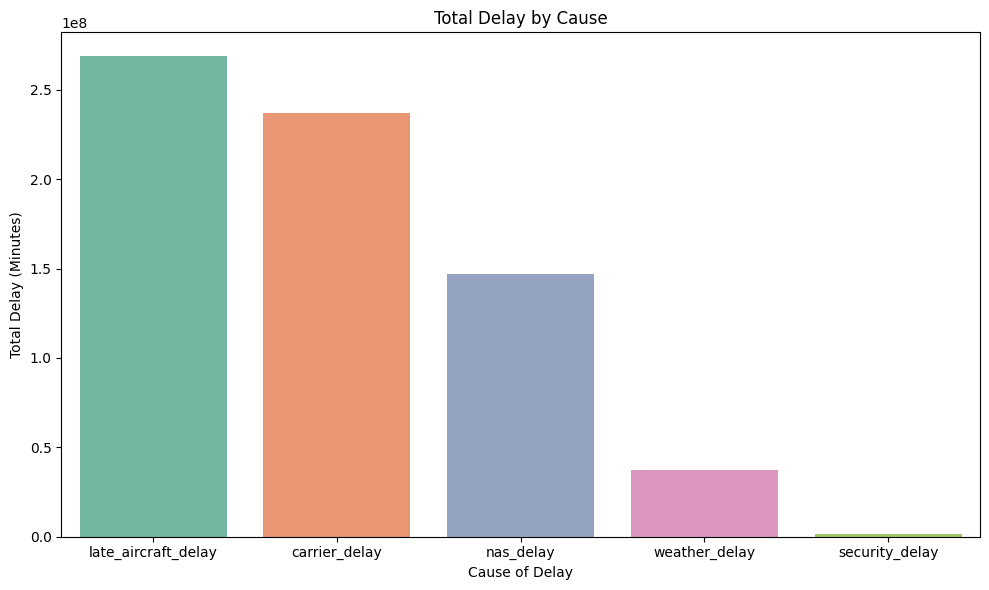

In [111]:
delay_causes = df[['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']].sum().sort_values(ascending=False)

# Bar plot of delay causes
plt.figure(figsize=(10, 6))
sns.barplot(x=delay_causes.index, y=delay_causes.values, palette='Set2')
plt.title('Total Delay by Cause')
plt.ylabel('Total Delay (Minutes)')
plt.xlabel('Cause of Delay')
plt.tight_layout()
plt.show()

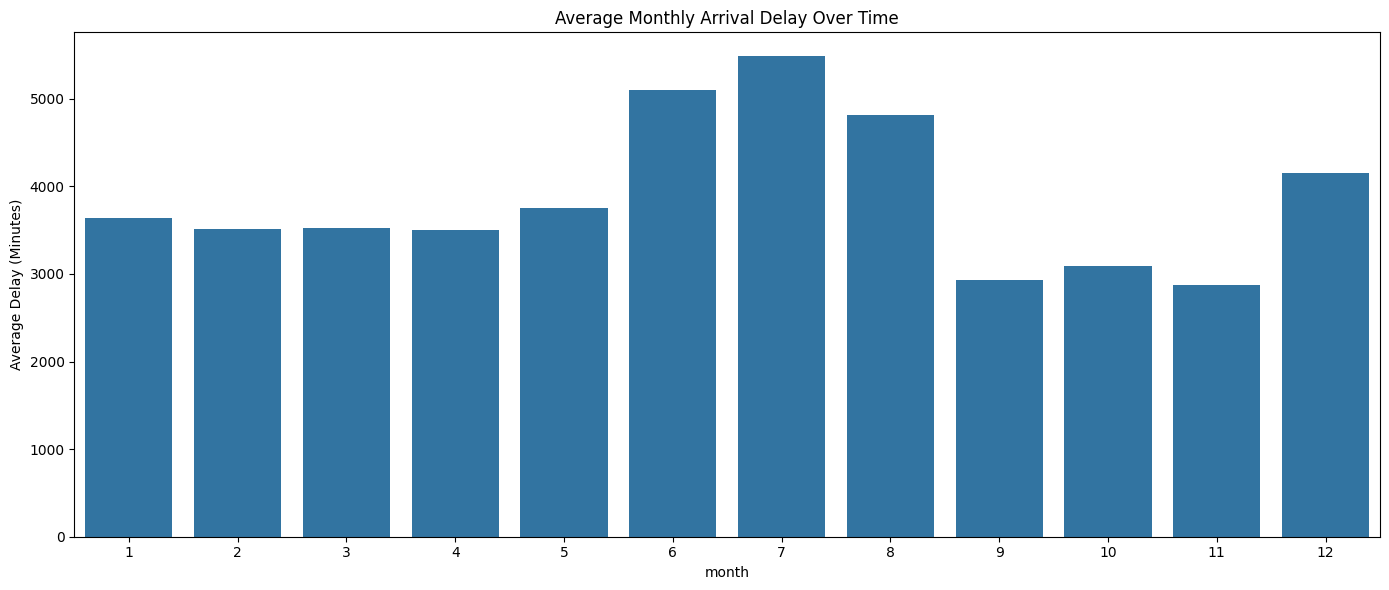

In [112]:
monthly_delay = df.groupby(['month'])['arr_delay'].mean()
#monthly_delay['date'] = pd.to_datetime(dict(year=monthly_delay.year, month=monthly_delay.month, day=1))

plt.figure(figsize=(14, 6))
sns.barplot(x=monthly_delay.index,y=monthly_delay.values)
plt.title('Average Monthly Arrival Delay Over Time')
plt.xlabel('month')
plt.ylabel('Average Delay (Minutes)')
plt.tight_layout()
plt.show()

In [119]:
carriers = df.groupby(['carrier'])['arr_delay'].mean()
carriers = carriers.sort_values(ascending=False)
carriers.shape

(29,)

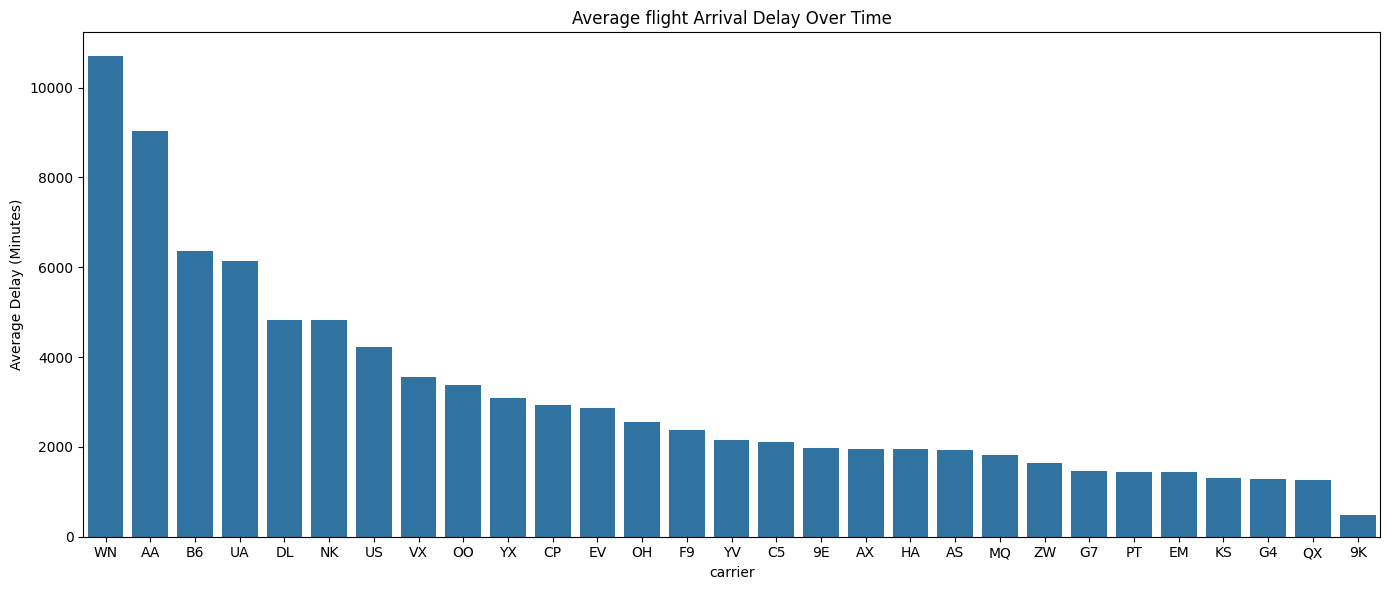

In [121]:
plt.figure(figsize=(14, 6))
sns.barplot(x=carriers.index,y=carriers.values)
plt.title('Average flight Arrival Delay Over Time')
plt.xlabel('carrier')
plt.ylabel('Average Delay (Minutes)')
plt.tight_layout()
plt.show()

In [114]:
airports = df.groupby(['airport']).agg(total_arr_delay=('arr_delay', 'sum'), total_arr_flights=('arr_flights', 'sum'))
airports['avg_delay_per_flight'] = airports['total_arr_delay'] / airports['total_arr_flights']
airports = airports.sort_values('avg_delay_per_flight', ascending=False)

top_airports=airports[airports['avg_delay_per_flight']>20]

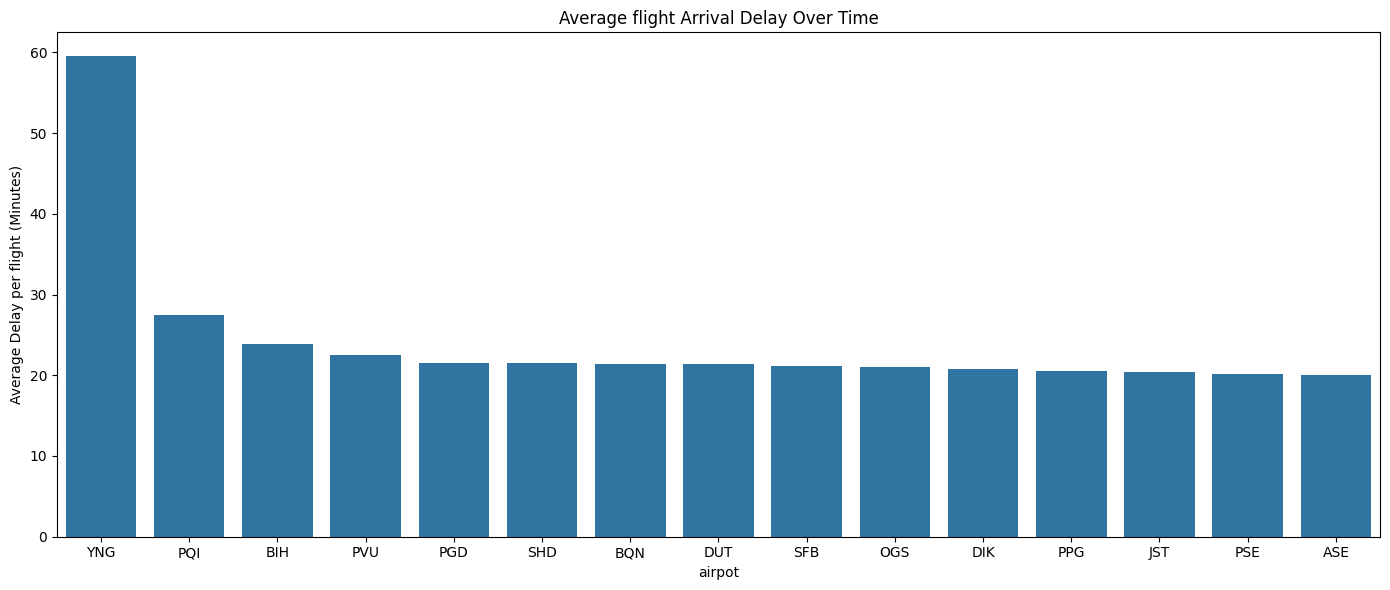

In [115]:
plt.figure(figsize=(14, 6))
sns.barplot(x=top_airports.index,y=top_airports['avg_delay_per_flight'])
plt.title('Average flight Arrival Delay Over Time')
plt.xlabel('airpot')
plt.ylabel('Average Delay per flight (Minutes)')
plt.tight_layout()
plt.show()

In [116]:
top_delay_months=df[df['month'].isin([6, 7, 8])]
display(top_delay_months.head())

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
7511,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
7512,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
7513,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
7514,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
7515,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


<ipython-input-117-1381255359>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delay_causes1.index, y=delay_causes1.values, palette='Set2')


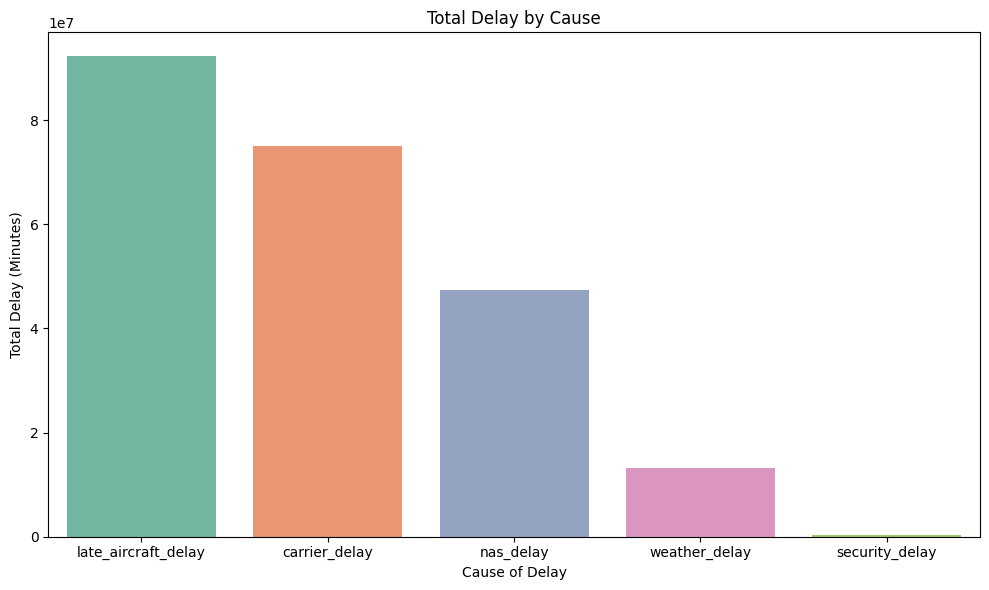

In [117]:
delay_causes1 = top_delay_months[['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']].sum().sort_values(ascending=False)

# Bar plot of delay causes
plt.figure(figsize=(10, 6))
sns.barplot(x=delay_causes1.index, y=delay_causes1.values, palette='Set2')
plt.title('Total Delay by Cause')
plt.ylabel('Total Delay (Minutes)')
plt.xlabel('Cause of Delay')
plt.tight_layout()
plt.show()